In [2]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
for dirname, _, filenames in os.walk('./archive'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./archive\test.csv
./archive\train.csv


In [4]:
# Reading the data set
df = pd.read_csv(r"archive\train.csv")
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [5]:
def load_dataset(label_dict):
    train_df = pd.read_csv(r'archive/train.csv')
    train_X = train_df.drop(columns=['Activity']).values
    train_y = train_df['Activity'].map(label_dict).values

    test_df = pd.read_csv(r'archive/test.csv')
    test_X = test_df.drop(columns=['Activity']).values
    test_y = test_df['Activity'].map(label_dict).values

    return train_X, train_y, test_X, test_y

label_dict = {
    'WALKING': 0, 
    'WALKING_UPSTAIRS': 1, 
    'WALKING_DOWNSTAIRS': 2, 
    'SITTING': 3, 
    'STANDING': 4, 
    'LAYING': 5
}

train_X, train_y, test_X, test_y = load_dataset(label_dict)

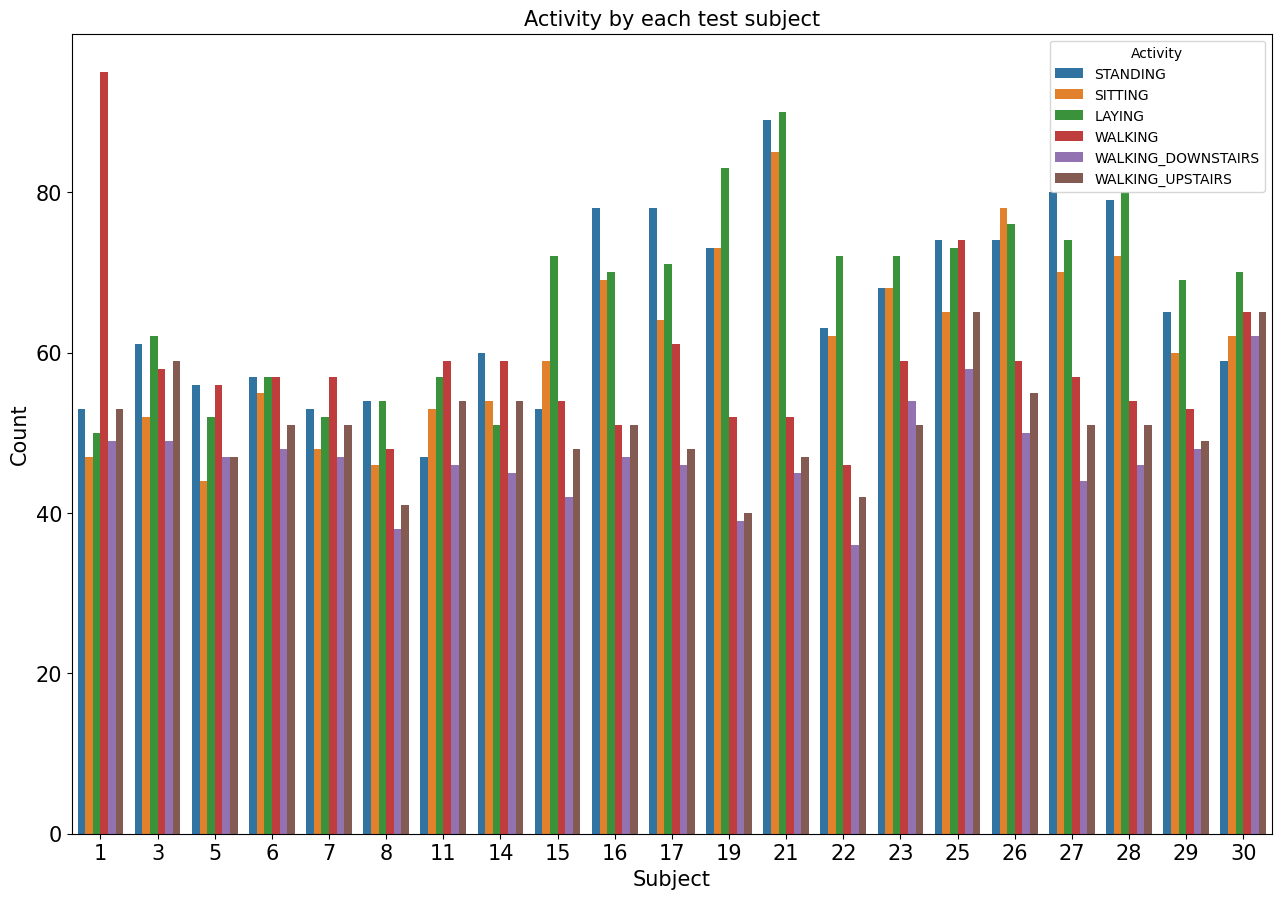

In [7]:
fig = plt.figure(figsize = (12, 8))
ax = fig.add_axes([0,0,1,1])
ax.set_title("Activity by each test subject", fontsize = 15)
plt.tick_params(labelsize = 15)
sns.countplot(x = "subject", hue = "Activity", data = df)
plt.xlabel("Subject", fontsize = 15)
plt.ylabel("Count", fontsize = 15)
plt.show()        

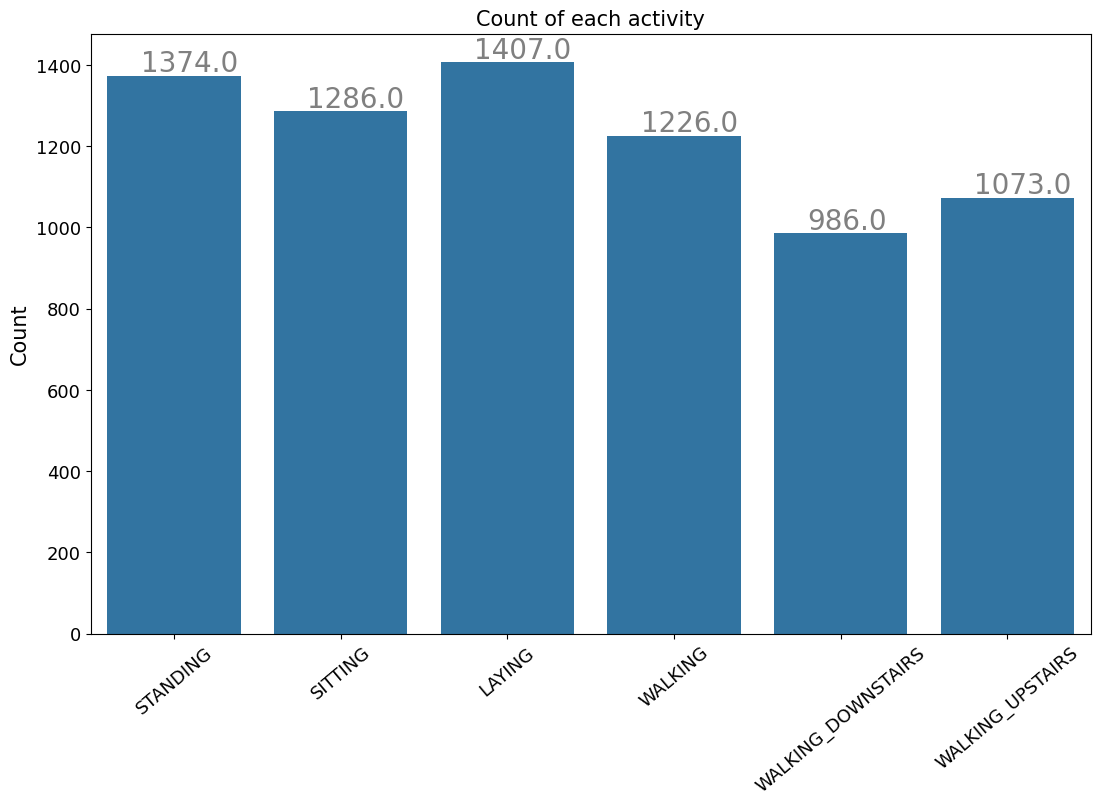

In [8]:
fig = plt.figure(figsize = (10, 6))
ax = fig.add_axes([0,0,1,1])
ax.set_title("Count of each activity", fontsize = 15)
plt.tick_params(labelsize = 10)
sns.countplot(x = "Activity", data = df)
for i in ax.patches:
    ax.text(x = i.get_x() + 0.2, y = i.get_height()+10, s = str(i.get_height()), fontsize = 20, color = "grey")
plt.xlabel("")
plt.ylabel("Count", fontsize = 15)
plt.tick_params(labelsize = 13)
plt.xticks(rotation = 40)
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [7]:
# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

logreg_model = LogisticRegression(C = 0.7)
knn_model = KNeighborsClassifier(algorithm='auto', n_neighbors=6)
gnb_model = GaussianNB()
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
svm_model = SVC(kernel='linear') 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


In [9]:
# Model Training
logreg_model.fit(train_X, train_y)
knn_model.fit(train_X, train_y)
gnb_model.fit(train_X, train_y)
mlp_model.fit(train_X, train_y)
svm_model.fit(train_X, train_y)
rf_model.fit(train_X, train_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
# Model evaluation
yhat_lgr = logreg_model.predict(test_X)
yhat_knn = knn_model.predict(test_X)
yhat_gnb = gnb_model.predict(test_X)
yhat_mlp = mlp_model.predict(test_X)
yhat_svm = svm_model.predict(test_X)
yhat_rf = rf_model.predict(test_X)

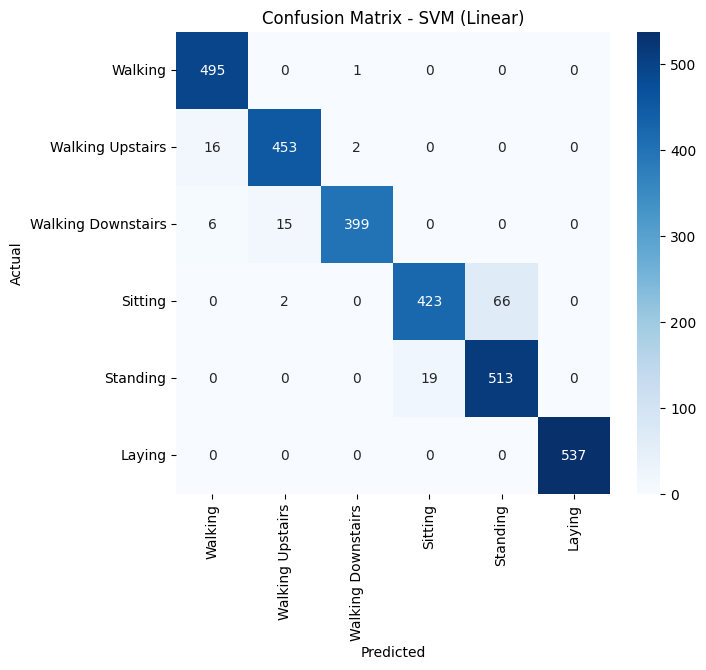

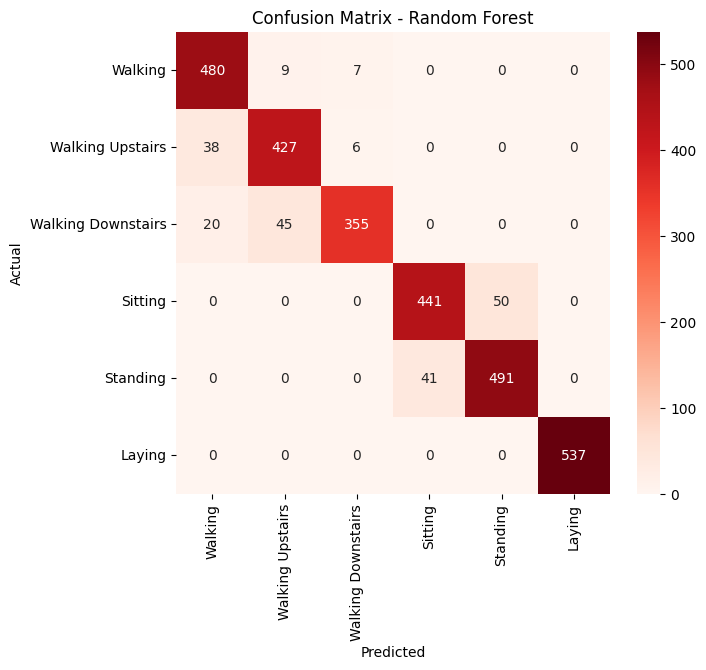

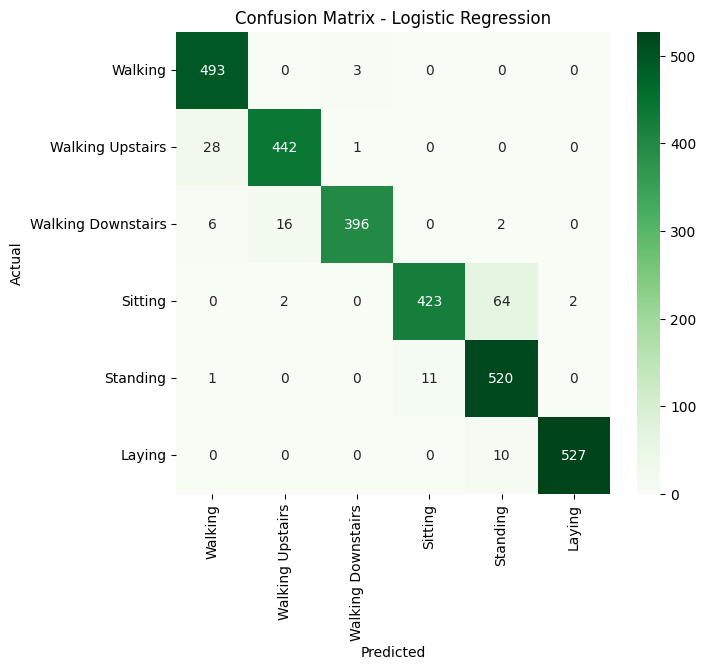

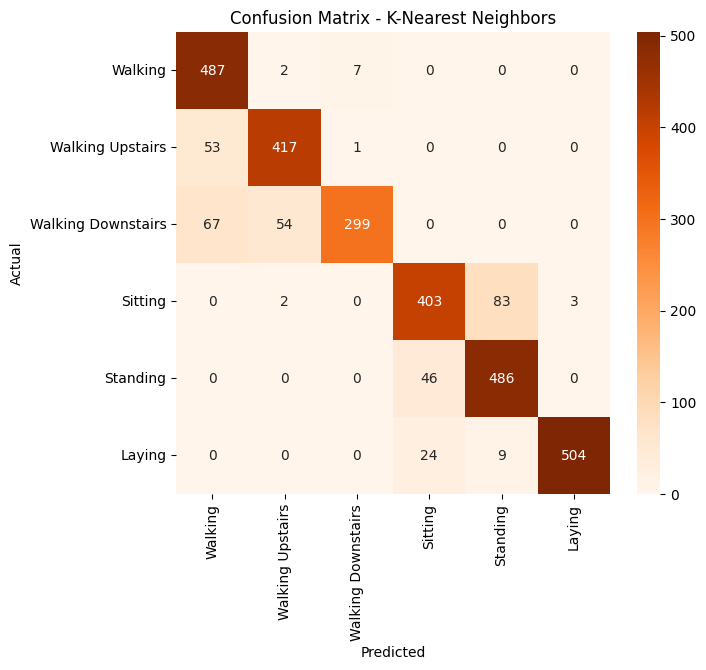

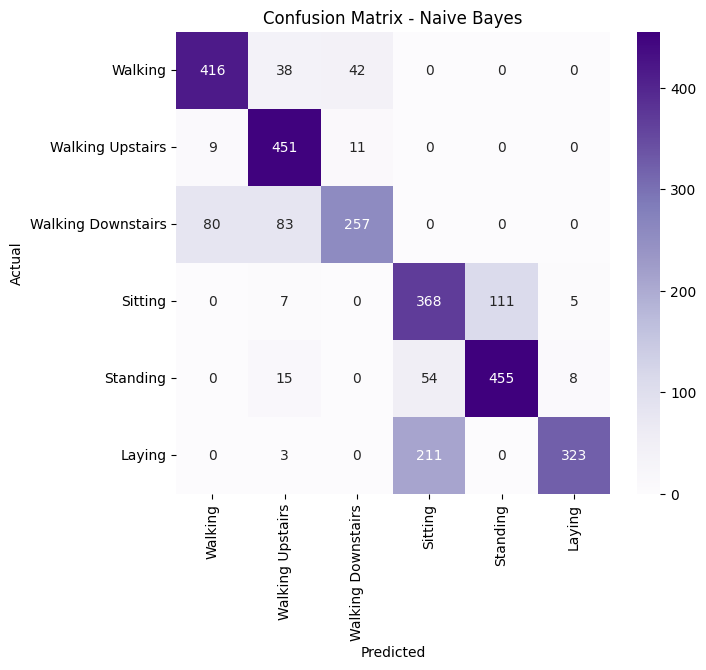

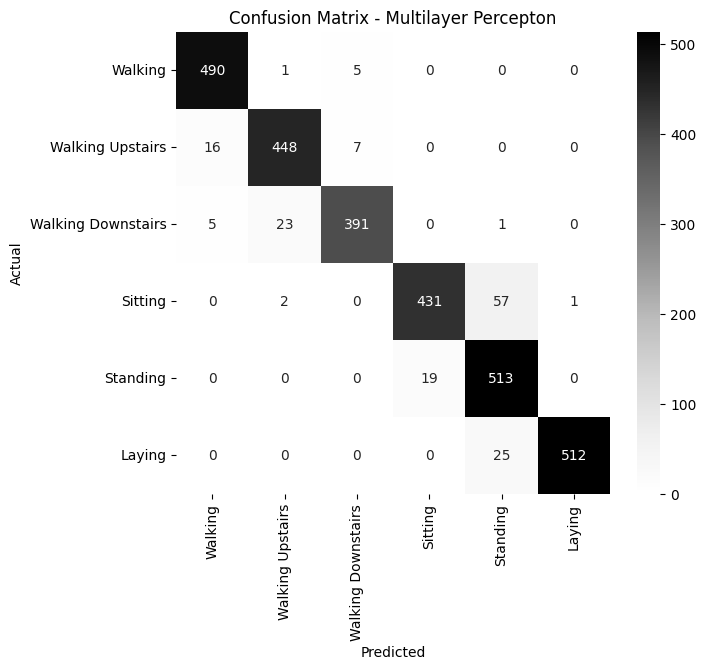

In [14]:
from sklearn.metrics import confusion_matrix
labels = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']
def plot_confusion_matrix(y_true, y_pred, title, cmap_color):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_color,
                xticklabels=labels,
                yticklabels=labels)
 
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
plot_confusion_matrix(test_y, yhat_svm, "Confusion Matrix - SVM (Linear)", "Blues")
plot_confusion_matrix(test_y, yhat_rf, "Confusion Matrix - Random Forest", "Reds")
plot_confusion_matrix(test_y, yhat_lgr, "Confusion Matrix - Logistic Regression", "Greens")
plot_confusion_matrix(test_y, yhat_knn, "Confusion Matrix - K-Nearest Neighbors", "Oranges")
plot_confusion_matrix(test_y, yhat_gnb, "Confusion Matrix - Naive Bayes", "Purples")
plot_confusion_matrix(test_y, yhat_mlp, "Confusion Matrix - Multilayer Percepton", "Greys")

In [58]:
yhat_lgr

array([4, 4, 4, ..., 1, 1, 1], shape=(2947,))

In [26]:
yhat_knn

array([4, 4, 4, ..., 1, 1, 0], shape=(2947,))

In [27]:
yhat_gnb

array([4, 4, 4, ..., 1, 1, 1], shape=(2947,))

In [ ]:
yhat_mlp

array([4, 4, 4, ..., 1, 1, 1], shape=(2947,))

In [29]:
yhat_svm

array([4, 4, 4, ..., 1, 1, 1], shape=(2947,))

In [30]:
yhat_rf

array([4, 4, 4, ..., 1, 1, 0], shape=(2947,))

In [59]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(test_y, yhat_lgr))
print("KNN:", accuracy_score(test_y, yhat_knn))
print("Naive Bayes:", accuracy_score(test_y, yhat_gnb))
print("MLP:", accuracy_score(test_y, yhat_mlp))
print("SVM:", accuracy_score(test_y, yhat_svm))
print("Random Forest:", accuracy_score(test_y, yhat_rf))

Logistic Regression: 0.9504580929759077
KNN: 0.8808958262639973
Naive Bayes: 0.7702748557855447
MLP: 0.9450288428910757
SVM: 0.9569053274516457
Random Forest: 0.9267051238547676


In [60]:
from sklearn.metrics import classification_report
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(classification_report(test_y, yhat_lgr, target_names=target_names))

                    precision    recall  f1-score   support

           Walking       0.93      0.99      0.96       496
  Walking Upstairs       0.96      0.94      0.95       471
Walking Downstairs       0.99      0.94      0.97       420
           Sitting       0.97      0.86      0.91       491
          Standing       0.87      0.98      0.92       532
            Laying       1.00      0.98      0.99       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [32]:
from sklearn.metrics import classification_report
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(classification_report(test_y, yhat_knn, target_names=target_names))

                    precision    recall  f1-score   support

           Walking       0.83      0.98      0.90       496
  Walking Upstairs       0.90      0.89      0.89       471
Walking Downstairs       0.96      0.76      0.85       420
           Sitting       0.88      0.86      0.87       491
          Standing       0.87      0.89      0.88       532
            Laying       1.00      0.99      1.00       537

          accuracy                           0.90      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.90      0.90      2947



In [33]:
from sklearn.metrics import classification_report
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(classification_report(test_y, yhat_gnb, target_names=target_names))

                    precision    recall  f1-score   support

           Walking       0.82      0.84      0.83       496
  Walking Upstairs       0.76      0.96      0.84       471
Walking Downstairs       0.83      0.61      0.70       420
           Sitting       0.58      0.75      0.65       491
          Standing       0.80      0.86      0.83       532
            Laying       0.96      0.60      0.74       537

          accuracy                           0.77      2947
         macro avg       0.79      0.77      0.77      2947
      weighted avg       0.79      0.77      0.77      2947



In [34]:
from sklearn.metrics import classification_report
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(classification_report(test_y, yhat_mlp, target_names=target_names))

                    precision    recall  f1-score   support

           Walking       0.93      0.99      0.96       496
  Walking Upstairs       0.92      0.93      0.93       471
Walking Downstairs       0.99      0.91      0.95       420
           Sitting       0.94      0.91      0.92       491
          Standing       0.90      0.95      0.92       532
            Laying       1.00      0.97      0.99       537

          accuracy                           0.95      2947
         macro avg       0.95      0.94      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [35]:
from sklearn.metrics import classification_report
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(classification_report(test_y, yhat_svm, target_names=target_names))

                    precision    recall  f1-score   support

           Walking       0.96      0.99      0.97       496
  Walking Upstairs       0.98      0.96      0.97       471
Walking Downstairs       0.99      0.98      0.98       420
           Sitting       0.96      0.89      0.92       491
          Standing       0.91      0.97      0.94       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.97      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



In [36]:
from sklearn.metrics import classification_report
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(classification_report(test_y, yhat_rf, target_names=target_names))

                    precision    recall  f1-score   support

           Walking       0.89      0.97      0.93       496
  Walking Upstairs       0.90      0.89      0.89       471
Walking Downstairs       0.97      0.87      0.91       420
           Sitting       0.91      0.89      0.90       491
          Standing       0.90      0.92      0.91       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947

